In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [3]:
df = pd.read_csv(r"C:\Users\chiru\OneDrive\Desktop\AFD\new.csv")

df.head()

,Age,Gender,Training_Hours,Training_Intensity,Resting_HeartRate,HeartRate_Recovery,Lactate_Level,RPE,Sleep_Hours,Sleep_Quality,Muscle_Soreness,Hydration_Level,Cortisol_Level,HRV,Protein_Intake,Fatigue_Risk
0,24,1,2.26,7,70,49.9,1.81,9,6.98,2,9,4.00,331.6,73.5,1.50,0
1,37,1,1.47,2,50,27.6,1.57,15,8.02,5,6,2.03,536.2,44.8,1.11,1
2,32,1,1.05,6,73,37.8,0.83,12,7.89,4,8,3.54,367.8,43.2,1.11,0
3,28,1,1.78,6,71,23.5,2.28,13,6.67,3,4,3.20,353.1,80.4,0.95,0
4,25,0,1.48,3,55,30.3,2.88,7,7.10,1,4,2.27,483.2,51.1,1.68,1


In [4]:
print(df.shape)

df.info()

display(df.describe())

print(df.isnull().sum())

print(df.duplicated().sum())

print(df["Fatigue_Risk"].value_counts())

(1000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1000 non-null   int64  
 1   Gender              1000 non-null   int64  
 2   Training_Hours      1000 non-null   float64
 3   Training_Intensity  1000 non-null   int64  
 4   Resting_HeartRate   1000 non-null   int64  
 5   HeartRate_Recovery  1000 non-null   float64
 6   Lactate_Level       1000 non-null   float64
 7   RPE                 1000 non-null   int64  
 8   Sleep_Hours         1000 non-null   float64
 9   Sleep_Quality       1000 non-null   int64  
 10  Muscle_Soreness     1000 non-null   int64  
 11  Hydration_Level     1000 non-null   float64
 12  Cortisol_Level      1000 non-null   float64
 13  HRV                 1000 non-null   float64
 14  Protein_Intake      1000 non-null   float64
 15  Fatigue_Risk        1000 non-null   int64  
d

,Age,Gender,Training_Hours,Training_Intensity,Resting_HeartRate,HeartRate_Recovery,Lactate_Level,RPE,Sleep_Hours,Sleep_Quality,Muscle_Soreness,Hydration_Level,Cortisol_Level,HRV,Protein_Intake,Fatigue_Risk
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,28.231000,0.478000,2.00222,5.015000,65.174000,24.440800,3.004340,12.349000,6.929530,3.052000,4.98100,2.490100,350.593900,59.80680,1.582210,0.489000
std,6.538378,0.499766,0.68733,2.617561,10.016889,9.661908,1.423546,4.099269,1.519732,1.419617,3.09681,0.564897,98.022017,15.58151,0.391026,0.500129
min,18.000000,0.000000,0.50000,1.000000,45.000000,5.000000,0.500000,6.000000,3.000000,1.000000,0.00000,1.500000,150.000000,20.00000,0.800000,0.000000
25%,22.000000,0.000000,1.52000,3.000000,58.000000,17.800000,2.010000,9.000000,5.870000,2.000000,2.00000,2.080000,279.900000,48.57500,1.310000,0.000000
50%,28.000000,0.000000,2.00500,5.000000,65.000000,24.500000,2.970000,12.000000,6.910000,3.000000,5.00000,2.490000,352.850000,60.10000,1.570000,0.000000
75%,34.000000,1.000000,2.45000,7.000000,72.000000,31.100000,3.980000,16.000000,8.042500,4.000000,8.00000,2.880000,414.900000,70.72500,1.850000,1.000000
max,39.000000,1.000000,4.08000,9.000000,100.000000,50.000000,7.670000,19.000000,10.000000,5.000000,10.00000,4.000000,628.500000,100.00000,2.840000,1.000000


Age                   0
Gender                0
Training_Hours        0
Training_Intensity    0
Resting_HeartRate     0
HeartRate_Recovery    0
Lactate_Level         0
RPE                   0
Sleep_Hours           0
Sleep_Quality         0
Muscle_Soreness       0
Hydration_Level       0
Cortisol_Level        0
HRV                   0
Protein_Intake        0
Fatigue_Risk          0
dtype: int64
0
Fatigue_Risk
0    511
1    489
Name: count, dtype: int64


In [5]:
selected_features = [
    "HRV",
    "HeartRate_Recovery",
    "Cortisol_Level",
    "Sleep_Quality",
    "Sleep_Hours",
    "Muscle_Soreness",
    "RPE",
    "Training_Hours",
    "Training_Intensity"
]

X = df[selected_features]
y = df["Fatigue_Risk"]

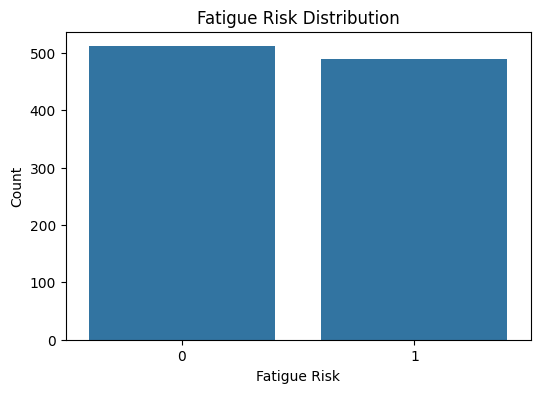

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(x=df["Fatigue_Risk"])

plt.title("Fatigue Risk Distribution")

plt.xlabel("Fatigue Risk")

plt.ylabel("Count")

plt.show()

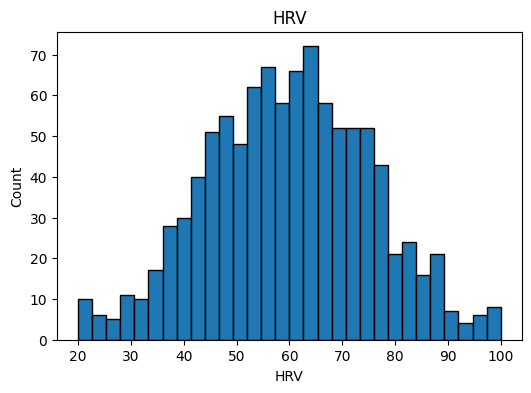

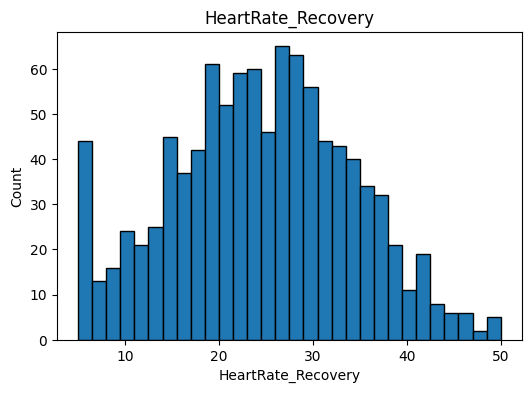

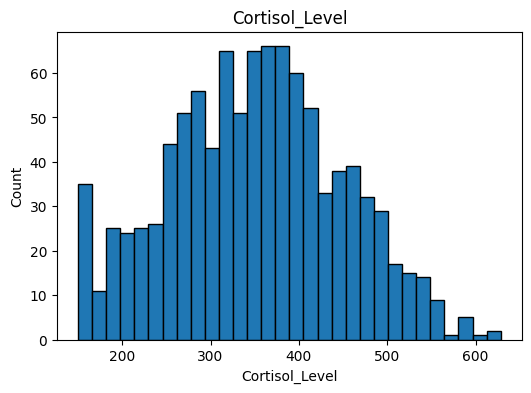

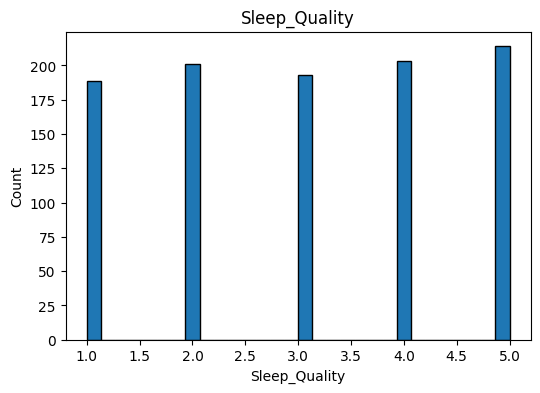

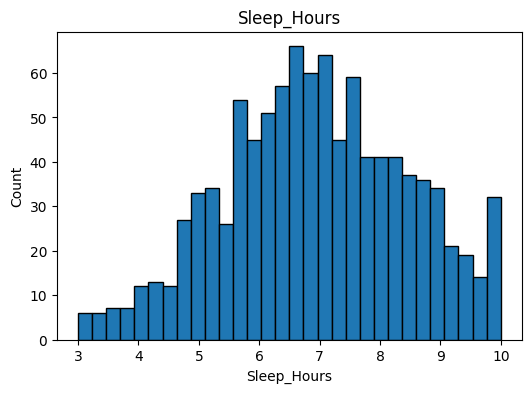

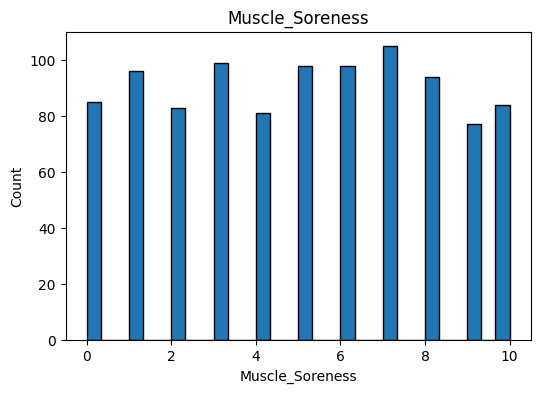

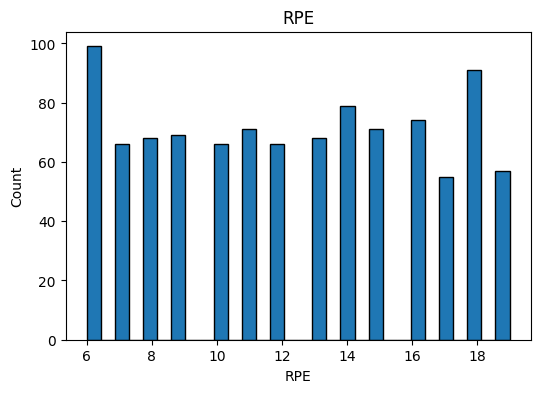

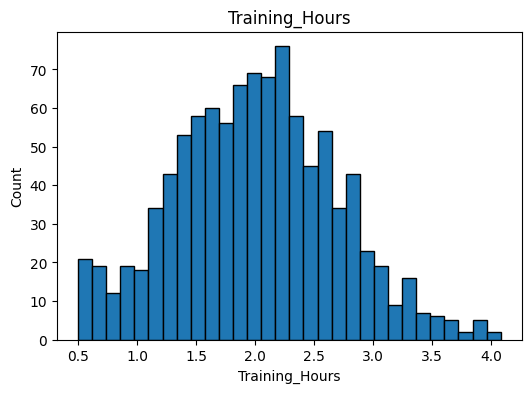

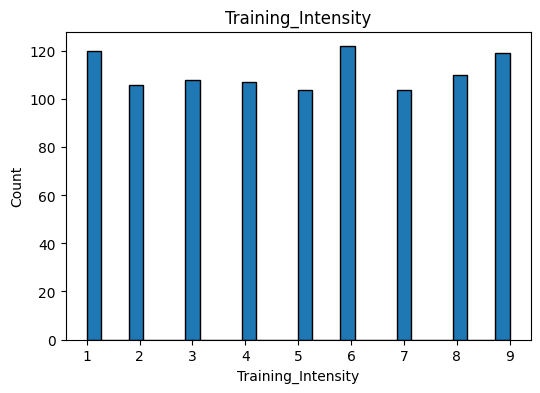

In [7]:
for col in X.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

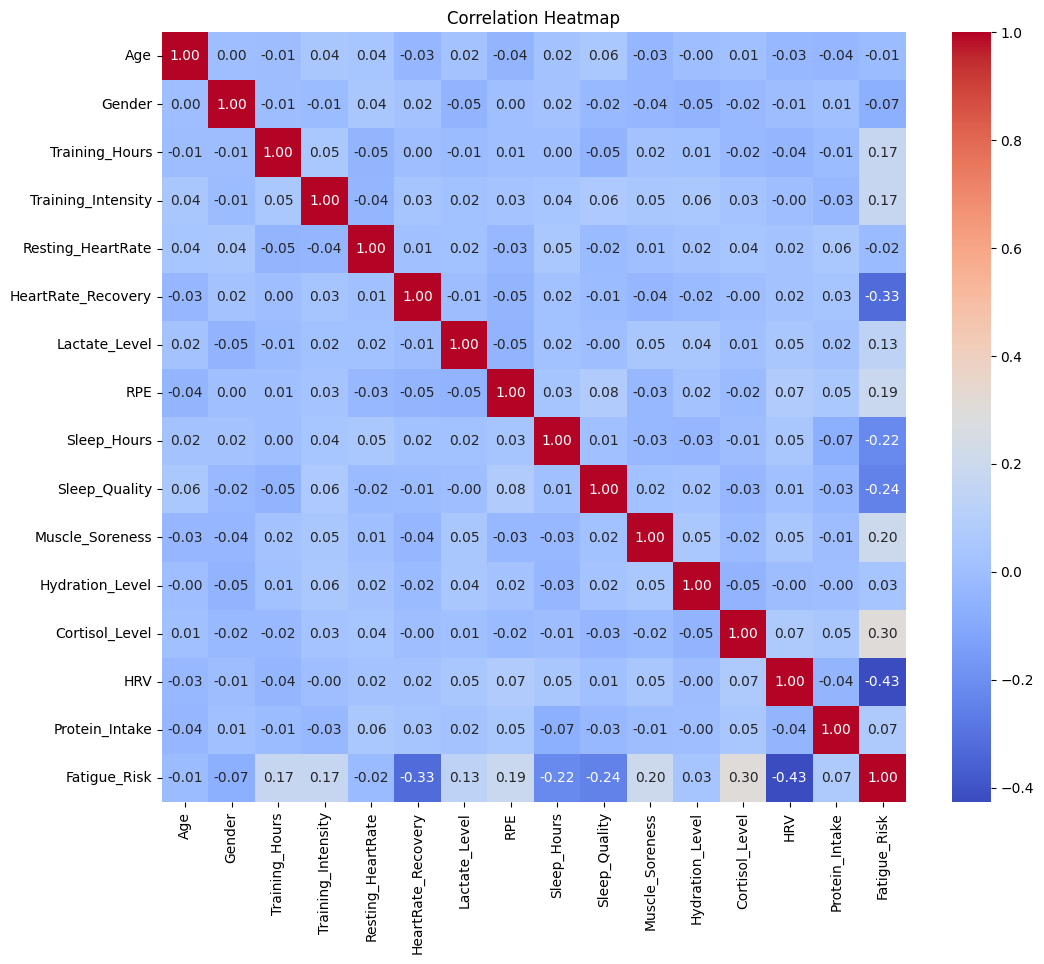

In [8]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

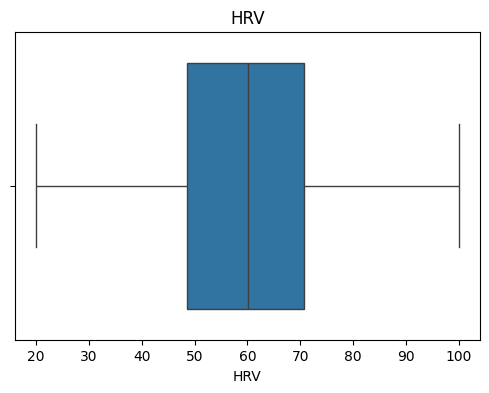

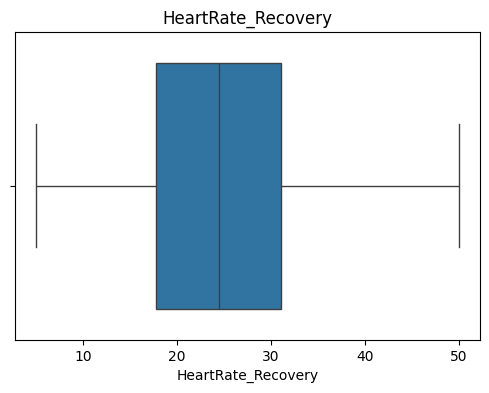

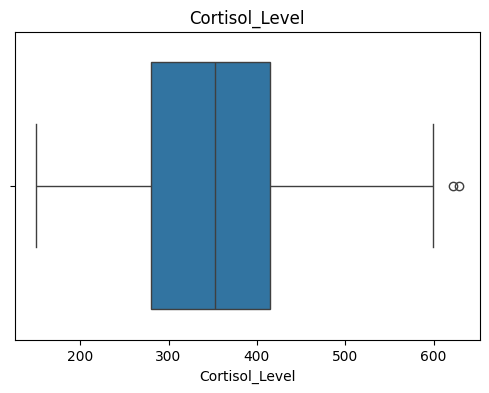

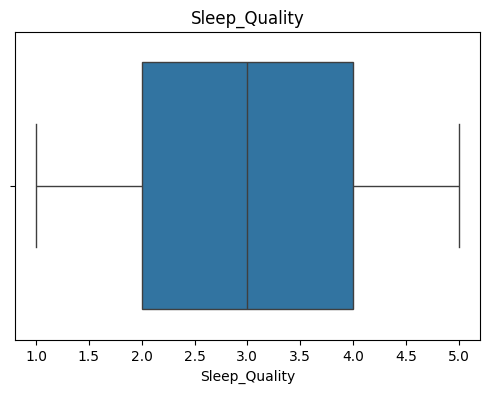

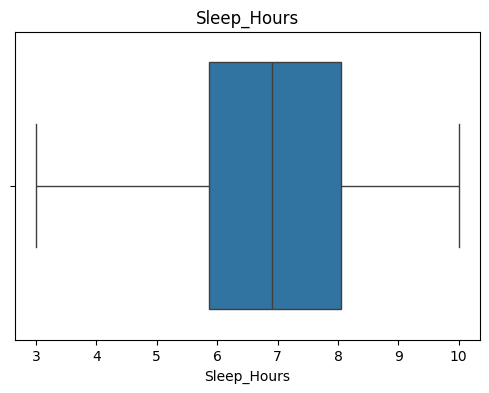

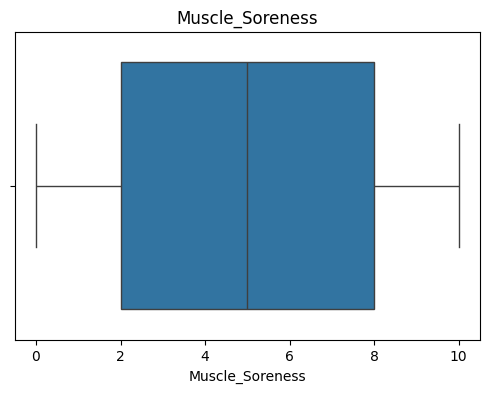

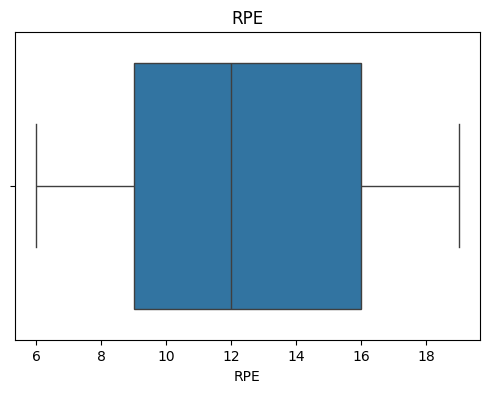

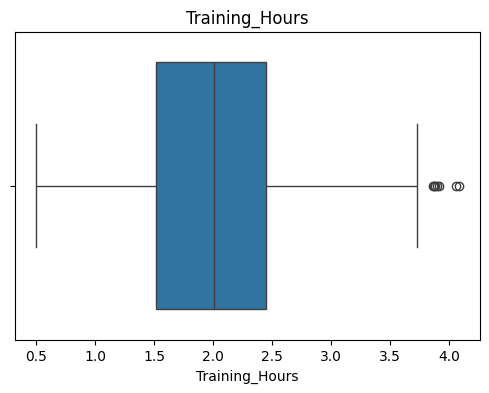

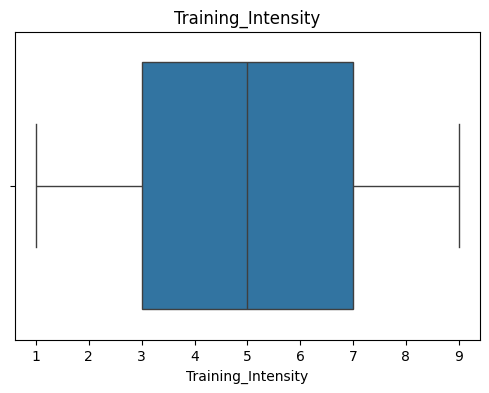

In [9]:
for col in X.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [10]:
print(df.isnull().sum())

Age                   0
Gender                0
Training_Hours        0
Training_Intensity    0
Resting_HeartRate     0
HeartRate_Recovery    0
Lactate_Level         0
RPE                   0
Sleep_Hours           0
Sleep_Quality         0
Muscle_Soreness       0
Hydration_Level       0
Cortisol_Level        0
HRV                   0
Protein_Intake        0
Fatigue_Risk          0
dtype: int64


In [11]:
print(df.duplicated().sum())    

0


In [12]:
selected_features = [
    "HRV",
    "HeartRate_Recovery",
    "Cortisol_Level",
    "Sleep_Quality",
    "Sleep_Hours",
    "Muscle_Soreness",
    "RPE",
    "Training_Hours",
    "Training_Intensity"
]

X = df[selected_features]
y = df["Fatigue_Risk"]

In [13]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: []
Numerical Columns: ['HRV', 'HeartRate_Recovery', 'Cortisol_Level', 'Sleep_Quality', 'Sleep_Hours', 'Muscle_Soreness', 'RPE', 'Training_Hours', 'Training_Intensity']


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols)
    ],
    remainder="passthrough"
)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 9)
(200, 9)
(800,)
(200,)


In [17]:
print(categorical_cols)
print(numerical_cols)

[]
['HRV', 'HeartRate_Recovery', 'Cortisol_Level', 'Sleep_Quality', 'Sleep_Hours', 'Muscle_Soreness', 'RPE', 'Training_Hours', 'Training_Intensity']


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

results = {}

for name, clf in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = {
        "pipeline": pipeline,
        "accuracy": accuracy
    }

    print(f"\n{name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, predictions))


Logistic Regression
Accuracy: 0.9500
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       102
           1       0.94      0.96      0.95        98

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200


Random Forest
Accuracy: 0.8650
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       102
           1       0.85      0.88      0.86        98

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.86       200
weighted avg       0.87      0.86      0.87       200


Gradient Boosting
Accuracy: 0.8700
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       102
           1       0.85      0.89      0.87        98

    accuracy                           0.87       200
   macro avg       0.8

In [19]:
best_model_name = max(
    results,
    key=lambda x: results[x]["accuracy"]
)

best_pipeline = results[best_model_name]["pipeline"]

print(best_model_name)
print(results[best_model_name]["accuracy"])

Logistic Regression
0.95


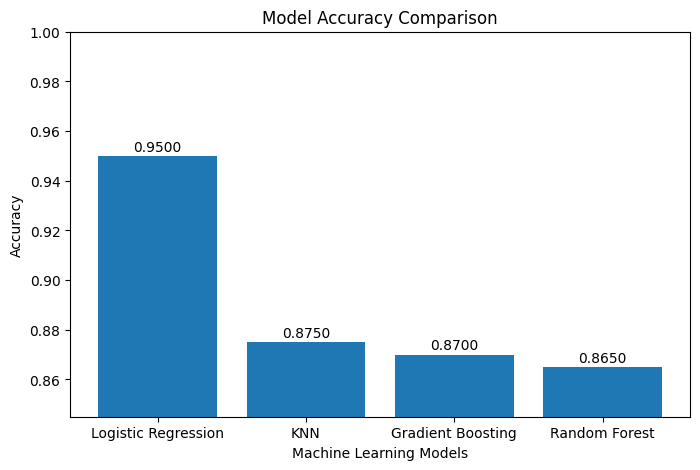

                 Model  Accuracy
0  Logistic Regression     0.950
3                  KNN     0.875
2    Gradient Boosting     0.870
1        Random Forest     0.865


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": [v["accuracy"] for v in results.values()]
})

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")
plt.ylim(
    comparison_df["Accuracy"].min() - 0.02,
    1.0
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha="center"
    )

plt.show()

print(comparison_df)

In [21]:
corr = df.corr(numeric_only=True)["Fatigue_Risk"].sort_values(ascending=False)
print(corr)

Fatigue_Risk          1.000000
Cortisol_Level        0.298458
Muscle_Soreness       0.202482
RPE                   0.186679
Training_Hours        0.170130
Training_Intensity    0.169493
Lactate_Level         0.131386
Protein_Intake        0.067203
Hydration_Level       0.031892
Age                  -0.011008
Resting_HeartRate    -0.017201
Gender               -0.067049
Sleep_Hours          -0.220110
Sleep_Quality        -0.244512
HeartRate_Recovery   -0.325322
HRV                  -0.427134
Name: Fatigue_Risk, dtype: float64


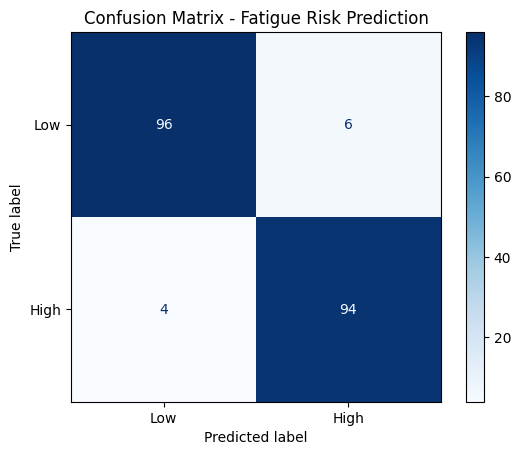

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "High"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Fatigue Risk Prediction")
plt.show()

In [23]:
import joblib

joblib.dump(best_pipeline, "fatigue_risk_model.pkl")

['fatigue_risk_model.pkl']

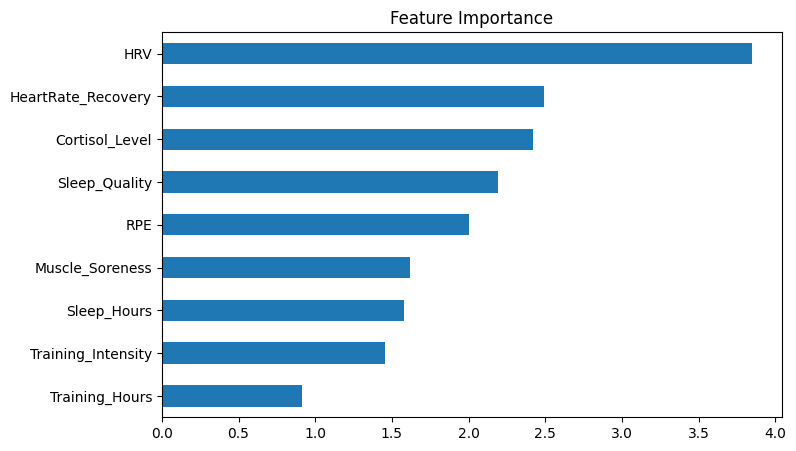

In [24]:
importance = pd.Series(
    abs(best_pipeline.named_steps['model'].coef_[0]),
    index=selected_features
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

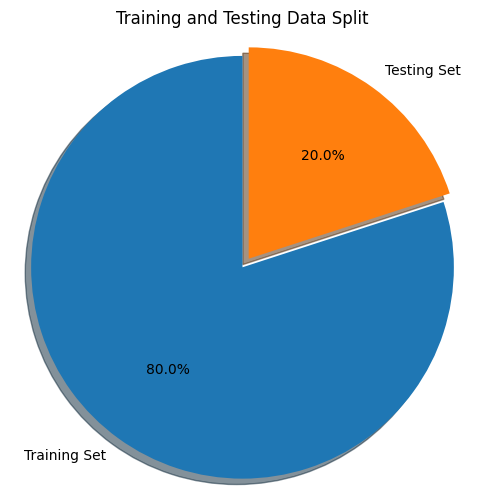

In [25]:
import matplotlib.pyplot as plt

train_size = len(X_train)
test_size = len(X_test)

sizes = [train_size, test_size]
labels = ["Training Set", "Testing Set"]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05, 0),
    shadow=True
)

plt.title("Training and Testing Data Split")
plt.axis("equal")

plt.show()